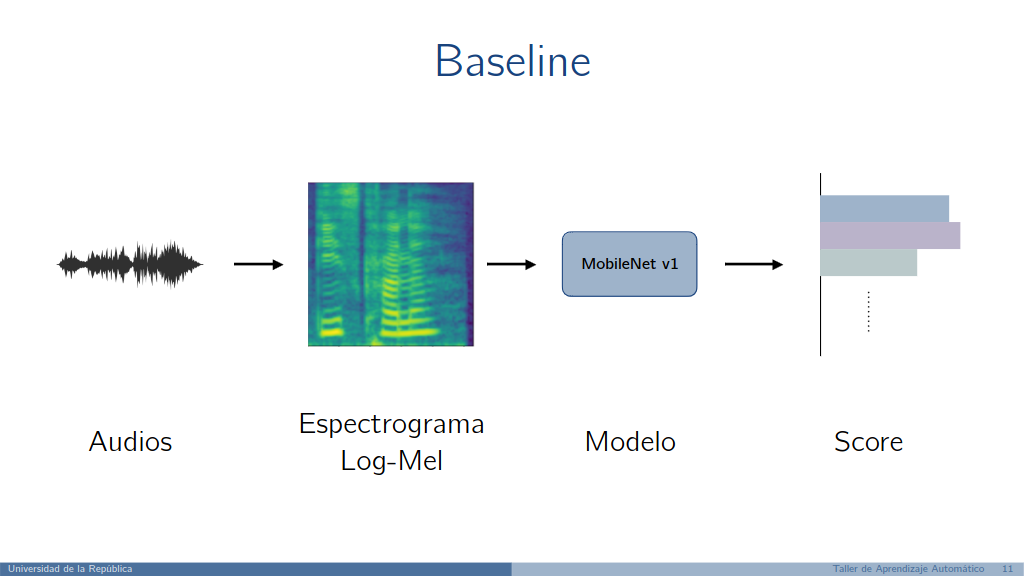

# Convert audio to images

In [10]:
import comet_ml
from comet_ml import Experiment

import importlib
import sys
sys.path.append("C:/Users/Valen/Desktop/Laboratorio-2-TAA/utils")

import images_dataset

importlib.reload(images_dataset)

BATCH_SIZE = 32

image_size = (224, 224)
preprocClass = images_dataset.ImagesDataset(image_dir='', audio_dir="../taa-2024-freesound-audio-tagging-v-1/train_curated_resampled", labels_csv="../taa-2024-freesound-audio-tagging-v-1/train_curated.csv", image_size=image_size, batch_size=BATCH_SIZE)
train_dataset, val_dataset, mlb = preprocClass.get_train_and_val_dataset_augmented()


Identified 80 unique labels for 4970 files.
Dividiendo archivos de audio en entrenamiento y validación...
../taa-2024-freesound-audio-tagging-v-1/train_curated_resampled
Archivos de entrenamiento movidos a: C:/Users/Valen/Desktop/Laboratorio-2-TAA/data/train_folder_resampled
Archivos de validación movidos a: C:/Users/Valen/Desktop/Laboratorio-2-TAA/data/val_folder_resampled
Augmenting dataset...
C:/Users/Valen/Desktop/Laboratorio-2-TAA/data/train_folder_resampled


100%|██████████| 3758/3758 [00:24<00:00, 154.87it/s]




















100%|██████████| 470/470 [00:02<00:00, 178.61it/s]


## Define model using MobileNetV2

In [43]:
import tensorflow as tf
import keras_tuner as kt

from lwlrap import LwLrap

num_classes = 80

def build_mobilenet(hp, learning_rate=1e-3, fine_tune=False, train_upto_layer=8*2 + 5): # train upto two last blocks
    dropout_rate = hp.Float("dropout_rate", min_value=0.001, max_value=0.1, sampling="log")
    # learning_rate = hp.Float("learning_rate", min_value=1e-5, max_value=1e-2, sampling="log")

    if not fine_tune:
        # Define layers
        preproc = tf.keras.Sequential([
            tf.keras.layers.Rescaling(scale=1./127.5, offset=-1)
        ])
        avg = tf.keras.layers.GlobalAveragePooling2D()
        dropout = tf.keras.layers.Dropout(dropout_rate)
        predict = tf.keras.layers.Dense(num_classes, activation="sigmoid")
        
        # Define model
        input = tf.keras.Input(shape=image_size + (3,))
        x = preproc(input)
        
        base_model = tf.keras.applications.MobileNet(
            input_shape=image_size + (3,),
            include_top=False,
            input_tensor=x,
            dropout=dropout_rate
        )

        for layer in base_model.layers:    
            layer.trainable = False
        
        x = avg(base_model.layers[-1].output)
        x = dropout(x)
        output = predict(x)
        model = tf.keras.Model(input, output)
        optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
    else:
        # Load pre-trained model and freeze
        model = tf.keras.models.load_model("baseline/best_mobilenetv2.keras", custom_objects={'lwlrap': LwLrap(num_classes)})
        for layer in model.layers[:len(model.layers) - train_upto_layer]:
            layer.trainable = False
        for layer in model.layers[len(model.layers) - train_upto_layer:]:
            layer.trainable = True
        # Set lower learning rate as to not overfit
        optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate / 100)
        
        x = model.layers[-2].output
        x = tf.keras.layers.Dropout(0.95)(x)
        output = model.layers[-1](x)
        model = tf.keras.Model(model.input, output)

    model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=[LwLrap(num_classes)])
    return model

## Run training experiment

In [20]:
api_key = "RJbMPPcJpbNG60g1DeDQV240w"
experiment = Experiment(
    api_key,
    project_name='baseline_mobilenet',
    auto_histogram_weight_logging=True,
    auto_histogram_gradient_logging=True,
    auto_histogram_activation_logging=True,
)

experiment.set_name("Pruebo con el dataset aumentado, fine-tuning de MobileNetV2 y dropout. Dropout en finetune = false")
experiment.add_tag("fine-tuning")
experiment.add_tag("dropout")
experiment.add_tag("augmented")


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET WARNING: Failing to collect the installed pip packages
COMET INFO: Experiment is live on comet.com https://www.comet.com/valenalaniz/baseline-mobilenet/924434f1a8a24cb9ad8176a43e81ca1a

COMET WARNING: Failed to add tag(s) fine-tuning to the experiment



## Search learning rate or use default one

In [23]:
params={'batch_size':16,
        'epochs':10,
        'epochs_fine_tune':100,
        'learning_rate':1e-3,
        'optimizer':"Nadam",
}

hyperband = kt.Hyperband(
    build_mobilenet,
    objective=kt.Objective("val_lwlrap", direction="max"),
    max_epochs=params["epochs"],
    overwrite=True,
    directory="baseline",
    project_name="mobilenetv2",
    seed=42
)

early = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
checkpoint = tf.keras.callbacks.ModelCheckpoint("baseline/best_mobilenetv2.keras", monitor='val_lwlrap', verbose=1, save_best_only=True, mode='max')

# realiza busqueda
hyperband.search(train_dataset, epochs=params["epochs"], validation_data=val_dataset, callbacks=[early, checkpoint])
best_hps = hyperband.get_best_hyperparameters(num_trials=1)[0]
experiment.log_parameters(best_hps.values)

# redefinir el mejor modelo y entrenar para guardar datos en comet
model = build_mobilenet(best_hps)
with experiment.train():
    history = model.fit(train_dataset, epochs=params["epochs"], validation_data=val_dataset, callbacks=[early, checkpoint])

with experiment.test():
    loss, lwlrap = model.evaluate(val_dataset)
    metrics = {
        'loss':loss,
        'lwlrap':lwlrap
    }
    experiment.log_metrics(metrics)

experiment.log_parameters(params)

experiment.log_curve("LwLrap entrenamiento", range(len(history.history["lwlrap"])), history.history["lwlrap"])
experiment.log_curve("LwLrap validacion", range(len(history.history["val_lwlrap"])), history.history["val_lwlrap"])
experiment.log_curve("Perdida entrenamiento", range(len(history.history["loss"])), history.history["loss"])
experiment.log_curve("Perdida validacion", range(len(history.history["val_loss"])), history.history["val_loss"])

experiment.end()

Trial 30 Complete [00h 04m 03s]
val_lwlrap: 0.5599187016487122

Best val_lwlrap So Far: 0.5653154850006104
Total elapsed time: 00h 57m 09s


COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Epoch 1/10
117/118 [============================>.] - ETA: 0s - loss: 0.1143 - lwlrap: 0.1273
Epoch 1: val_lwlrap improved from -inf to 0.22631, saving model to baseline\best_mobilenetv2.keras
118/118 [==============================] - 26s 59ms/step - loss: 0.1139 - lwlrap: 0.1280 - val_loss: 0.0720 - val_lwlrap: 0.2263
Epoch 2/10
117/118 [============================>.] - ETA: 0s - loss: 0.0649 - lwlrap: 0.3121
Epoch 2: val_lwlrap improved from 0.22631 to 0.35557, saving model to baseline\best_mobilenetv2.keras
118/118 [==============================] - 23s 54ms/step - loss: 0.0648 - lwlrap: 0.3133 - val_loss: 0.0626 - val_lwlrap: 0.3556
Epoch 3/10
117/118 [============================>.] - ETA: 0s - loss: 0.0560 - lwlrap: 0.4447
Epoch 3: val_lwlrap improved from 0.35557 to 0.44860, saving model to baseline\best_mobilenetv2.keras
118/118 [==============================] - 22s 55ms/step - loss: 0.0561 - lwlrap: 0.4448 - val_loss: 0.0569 - val_lwlrap: 0.4486
Epoch 4/10
117/118 [========

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Pruebo con el dataset aumentado, fine-tuning de MobileNetV2 y dropout. Dropout en finetune = false
COMET INFO:     url                   : https://www.comet.com/valenalaniz/baseline-mobilenet/924434f1a8a24cb9ad8176a43e81ca1a
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     batch_loss [1476]                : (0.026459507644176483, 0.9074289202690125)
COMET INFO:     batch_lwlrap [1476]              : (0.02552752010524273, 0.9026650190353394)
COMET INFO:     epoch_duration [123]             : (21.39000000001397, 43.42200000002049)
COMET INFO:     loss [123]                       : (0.03182413429021835, 0.748124361038208)
COMET INFO:     lwlrap

## Unfreeze base model and fine tune

In [24]:
api_key = "RJbMPPcJpbNG60g1DeDQV240w"
experiment = Experiment(
    api_key,
    project_name='baseline_mobilenet',
    auto_histogram_weight_logging=True,
    auto_histogram_gradient_logging=True,
    auto_histogram_activation_logging=True,
)
experiment.set_name("MobilenetV2 Baseline Fine-tune Resampled Augmented LogMel Dropout(base model) y Dropout en fine-tune")
experiment.add_tag("fine-tuning")
experiment.add_tag("dropout")
experiment.add_tag("augmented")

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET ERROR: Failed to establish a connection to Comet server. Please check your internet connection. Your experiment will not be logged 
For more details, please refer to: https://www.comet.com/docs/v2/api-and-sdk/python-sdk/warnings-errors/


In [29]:
best_hps.values

{'dropout_rate': 0.001216554101262462,
 'tuner/epochs': 10,
 'tuner/initial_epoch': 4,
 'tuner/bracket': 1,
 'tuner/round': 1,
 'tuner/trial_id': '0021'}

In [45]:
model = build_mobilenet(best_hps, fine_tune=True)

early = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
checkpoint = tf.keras.callbacks.ModelCheckpoint("baseline/best_mobilenetv2_finetuned.keras", monitor='val_lwlrap', verbose=1, save_best_only=True, mode='max')

with experiment.train():
    history = model.fit(train_dataset, epochs=params["epochs_fine_tune"], validation_data=val_dataset, callbacks=[early, checkpoint])
    
with experiment.test():
    loss, lwlrap = model.evaluate(val_dataset)
    metrics = {
        'loss':loss,
        'lwlrap':lwlrap
    }
    experiment.log_metrics(metrics)
    
experiment.log_parameters(params)
experiment.log_curve("LwLrap entrenamiento", range(len(history.history["lwlrap"])), history.history["lwlrap"])
experiment.log_curve("LwLrap validacion", range(len(history.history["val_lwlrap"])), history.history["val_lwlrap"])
experiment.log_curve("Perdida entrenamiento", range(len(history.history["loss"])), history.history["loss"])
experiment.log_curve("Perdida validacion", range(len(history.history["val_loss"])), history.history["val_loss"])
experiment.end()

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Epoch 1/100
117/118 [============================>.] - ETA: 0s - loss: 0.4595 - lwlrap: 0.1330
Epoch 1: val_lwlrap improved from -inf to 0.41527, saving model to baseline\best_mobilenetv2_finetuned.keras
118/118 [==============================] - 27s 62ms/step - loss: 0.4591 - lwlrap: 0.1324 - val_loss: 0.0673 - val_lwlrap: 0.4153
Epoch 2/100
118/118 [==============================] - ETA: 0s - loss: 0.4455 - lwlrap: 0.1295
Epoch 2: val_lwlrap did not improve from 0.41527
118/118 [==============================] - 25s 59ms/step - loss: 0.4455 - lwlrap: 0.1295 - val_loss: 0.1045 - val_lwlrap: 0.2818
Epoch 3/100
118/118 [==============================] - ETA: 0s - loss: 0.4176 - lwlrap: 0.1342
Epoch 3: val_lwlrap did not improve from 0.41527
118/118 [==============================] - 24s 57ms/step - loss: 0.4176 - lwlrap: 0.1342 - val_loss: 0.1222 - val_lwlrap: 0.2439
Epoch 4/100
117/118 [============================>.] - ETA: 0s - loss: 0.4040 - lwlrap: 0.1320
Epoch 4: val_lwlrap did no

: 

In [39]:
model = build_mobilenet(best_hps, fine_tune=True)
# Configurar callbacks
early = tf.keras.callbacks.EarlyStopping(monitor='val_lwlrap', patience=10, restore_best_weights=True, mode='max')
checkpoint = tf.keras.callbacks.ModelCheckpoint("baseline/best_mobilenetv2_finetuned.keras", monitor='val_lwlrap', verbose=1, save_best_only=True, mode='max')

# Entrenar el modelo
with experiment.train():
    history = model.fit(train_dataset, epochs=100, validation_data=val_dataset, callbacks=[early, checkpoint])
    
# Evaluar el modelo
with experiment.test():
    loss, lwlrap = model.evaluate(val_dataset)
    metrics = {
        'loss': loss,
        'lwlrap': lwlrap
    }
    experiment.log_metrics(metrics)

# Registrar parámetros y curvas
experiment.log_parameters(params)
experiment.log_curve("LwLrap entrenamiento", range(len(history.history["lwlrap"])), history.history["lwlrap"])
experiment.log_curve("LwLrap validacion", range(len(history.history["val_lwlrap"])), history.history["val_lwlrap"])
experiment.log_curve("Perdida entrenamiento", range(len(history.history["loss"])), history.history["loss"])
experiment.log_curve("Perdida validacion", range(len(history.history["val_loss"])), history.history["val_loss"])
experiment.end()

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Epoch 1/100
118/118 [==============================] - ETA: 0s - loss: 0.1256 - lwlrap: 0.2388
Epoch 1: val_lwlrap improved from -inf to 0.44445, saving model to baseline\best_mobilenetv2_finetuned.keras
118/118 [==============================] - 26s 61ms/step - loss: 0.1256 - lwlrap: 0.2388 - val_loss: 0.0659 - val_lwlrap: 0.4445
Epoch 2/100
117/118 [============================>.] - ETA: 0s - loss: 0.1123 - lwlrap: 0.2803
Epoch 2: val_lwlrap did not improve from 0.44445
118/118 [==============================] - 23s 56ms/step - loss: 0.1121 - lwlrap: 0.2812 - val_loss: 0.0940 - val_lwlrap: 0.3581
Epoch 3/100
117/118 [============================>.] - ETA: 0s - loss: 0.1009 - lwlrap: 0.3281
Epoch 3: val_lwlrap did not improve from 0.44445
118/118 [==============================] - 23s 57ms/step - loss: 0.1009 - lwlrap: 0.3283 - val_loss: 0.0996 - val_lwlrap: 0.3616
Epoch 4/100
117/118 [============================>.] - ETA: 0s - loss: 0.0926 - lwlrap: 0.3598
Epoch 4: val_lwlrap did no

KeyboardInterrupt: 

In [40]:
# Evaluar el modelo
with experiment.test():
    loss, lwlrap = model.evaluate(val_dataset)
    metrics = {
        'loss': loss,
        'lwlrap': lwlrap
    }
    experiment.log_metrics(metrics)

# Registrar parámetros y curvas
experiment.log_parameters(params)
experiment.log_curve("LwLrap entrenamiento", range(len(history.history["lwlrap"])), history.history["lwlrap"])
experiment.log_curve("LwLrap validacion", range(len(history.history["val_lwlrap"])), history.history["val_lwlrap"])
experiment.log_curve("Perdida entrenamiento", range(len(history.history["loss"])), history.history["loss"])
experiment.log_curve("Perdida validacion", range(len(history.history["val_loss"])), history.history["val_loss"])
experiment.end()

15/15 [==============================] - 3s 150ms/step - loss: 0.0500 - lwlrap: 0.6177


# Load fine-tuned model and generate submission

In [ ]:
model = tf.keras.models.load_model("baseline/best_mobilenetv2_finetuned.keras")
submission = images.gen_submission(model, image_size=image_size)

In [ ]:
submission.head()
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ sequential[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis

 Total params: 2,565,427 (9.79 MB)

 Trainable params: 102,480 (400.31 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 204,963 (800.64 KB)

In [ ]:
!kaggle competitions submit -c taa-2024-freesound-audio-tagging-v-1 -f submission.csv -m "Test submission"

100%|██████████████████████████████████████| 4.47M/4.47M [00:01<00:00, 2.42MB/s]
Successfully submitted to TAA 2024 - Freesound Audio Tagging